# 02b — EfficientNet-B0 with 4 unfrozen blocks

In run 02, EfficientNet-B0 only fine-tuned its last 2 blocks (28% of its weights) at lr 1e-5 and was still under-fitting (93.7% val acc) while ResNet-18 (94% of weights fine-tuned) reached 99.0%.
Here we unfreeze the last **4** blocks (**92%** of weights — comparable to ResNet) and fine-tune with **lr 1e-4**.

**Kaggle:** Add Input → *140k Real and Fake Faces* **and** Add Input → Your Work → output of the *02 training* notebook; Accelerator = GPU; Internet = On; then *Save Version → Save & Run All*.

The output of this notebook contains the new `efficientnet_best.pth` **and** `resnet_best.pth`, so notebooks 03/04 only need this notebook's output attached.

Theory: [`docs/04_training.md`](../docs/04_training.md)

In [1]:
# --- environment setup: works on Kaggle, Colab and locally ---
import sys, os
REPO = "https://github.com/Mohd2Shaan/Deepfake-Detection-Project.git"
ON_KAGGLE = os.path.exists("/kaggle/input")
ON_COLAB = "google.colab" in sys.modules
if ON_KAGGLE or ON_COLAB:
    PROJECT = "/kaggle/working/project" if ON_KAGGLE else "/content/project"
    if os.path.exists(PROJECT):
        !git -C {PROJECT} pull -q
    else:
        !git clone -q {REPO} {PROJECT}
    %cd {PROJECT}
    EXTRA = "" if ON_KAGGLE else "kagglehub"
    !pip install -q grad-cam {EXTRA}
elif os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())
print("working dir:", os.getcwd())

/kaggle/working/project
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 1.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
working dir: /kaggle/working/project


In [2]:
# --- dataset: Kaggle -> attached input is found automatically; Colab/local -> downloaded once (~4 GB) ---
from src import config
if ON_KAGGLE:
    for ckpt in config.import_kaggle_checkpoints():      # notebooks 03/04: models from notebook 02's output
        print("trained model:", ckpt)
if not (config.DATA_DIR / "train").exists():
    if ON_KAGGLE:
        raise RuntimeError("Dataset not found - attach '140k Real and Fake Faces' with Add Input")
    !python scripts/download_dataset.py --move
print("data dir:", config.DATA_DIR)

trained model: /kaggle/working/project/checkpoints/resnet_best.pth
trained model: /kaggle/working/project/checkpoints/efficientnet_best.pth
data dir: /kaggle/input/datasets/xhlulu/140k-real-and-fake-faces/real_vs_fake/real-vs-fake


In [3]:
import torch
print('GPU:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'none')

GPU: Tesla T4


## Keep the run-02 EfficientNet for comparison
The setup cell copied run 02's checkpoints into `checkpoints/`. Save the old EfficientNet under a different name before it is overwritten (only `*_best.pth` files are picked up by evaluation and the app).

In [4]:
!cp checkpoints/efficientnet_best.pth checkpoints/efficientnet_2blocks.pth
!ls -lh checkpoints

total 74M
-rw-r--r-- 1 root root 16M Oct  6 12:26 efficientnet_2blocks.pth
-rw-r--r-- 1 root root 16M Oct  6 12:26 efficientnet_best.pth
-rw-r--r-- 1 root root 43M Oct  6 12:26 resnet_best.pth


## Train — 3 frozen epochs, then 7 epochs with the last 4 blocks unfrozen at lr 1e-4

In [5]:
!python -m src.train --model efficientnet_b0 --checkpoint-dir checkpoints --num-workers 4 --unfreeze-blocks 4 --lr-finetune 1e-4

device: cuda
train 100000 | valid 20000 images
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|███████████████████████████████████████| 20.5M/20.5M [00:00<00:00, 137MB/s]

=== phase: frozen | lr 0.0001 | trainable params 1,281 ===
epoch  1/10 [frozen  ] train loss 0.5699 acc 0.7116 | val loss 0.5032 acc 0.7583 | lr 1.0e-04 | 1302s *best*
epoch  2/10 [frozen  ] train loss 0.5091 acc 0.7563 | val loss 0.4682 acc 0.7833 | lr 1.0e-04 | 423s *best*
epoch  3/10 [frozen  ] train loss 0.4908 acc 0.7669 | val loss 0.4566 acc 0.7863 | lr 1.0e-04 | 414s *best*

=== phase: finetune | lr 0.0001 | trainable params 3,700,169 ===
epoch  4/10 [finetune] train loss 0.1484 acc 0.9394 | val loss 0.0238 acc 0.9918 | lr 1.0e-04 | 454s *best*
epoch  5/10 [finetune] train loss 0.0499 acc 0.9821 | val loss 0.0107 acc 0.9962 | lr 1.0e-04 | 444s *best*
epoch  6/10 [finetune] train loss 0.03

## Training curves

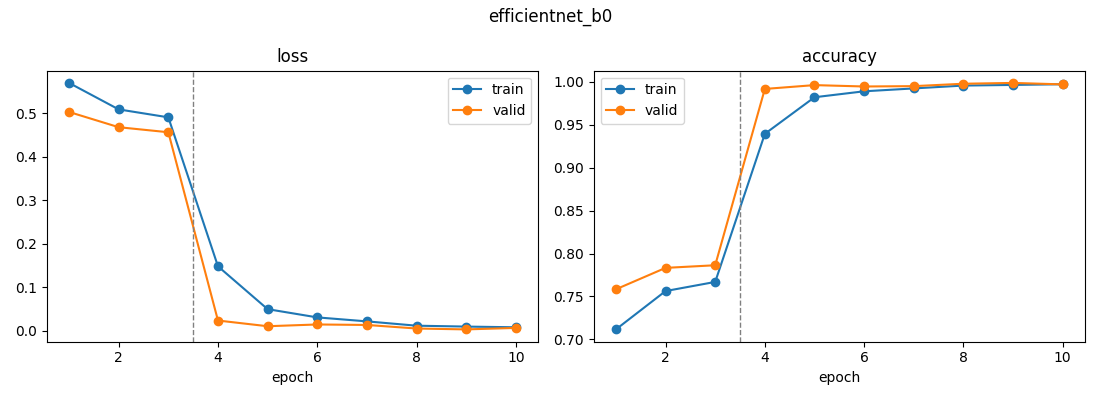

In [6]:
from IPython.display import Image as Show
Show('outputs/plots/training_curves_efficientnet.png')

## Package for download

In [7]:
!zip -qr results_02b.zip outputs checkpoints/efficientnet_best.pth checkpoints/resnet_best.pth checkpoints/efficientnet_2blocks.pth
!ls -lh results_02b.zip checkpoints

-rw-r--r-- 1 root root  69M Oct  6 13:54 results_02b.zip

checkpoints:
total 118M
-rw-r--r-- 1 root root 16M Oct  6 12:26 efficientnet_2blocks.pth
-rw-r--r-- 1 root root 16M Oct  6 13:47 efficientnet_best.pth
-rw-r--r-- 1 root root 44M Oct  6 13:54 efficientnet_last.pth
-rw-r--r-- 1 root root 43M Oct  6 12:26 resnet_best.pth


## Observations (Kaggle Tesla T4, ~90 min)

| Run | Unfrozen blocks | Fine-tuned params | Fine-tune lr | Best epoch | Val loss | Val accuracy |
|-----|-----------------|-------------------|--------------|-----------|----------|--------------|
| 02 — EfficientNet-B0 | 2 | 1.13 M (28%) | 1e-5 | 10 | 0.1581 | 93.71% |
| **02b — EfficientNet-B0** | **4** | **3.70 M (92%)** | **1e-4** | **9** | **0.0034** | **99.88%** |
| 02 — ResNet-18 | 2 (`layer3`, `layer4`) | 10.49 M (94%) | 1e-5 | 10 | 0.0290 | 98.96% |

1. **Under-fitting fixed.** Unfreezing more of the network and a 10× larger fine-tune learning rate took EfficientNet
   from 93.7% to **99.88%** validation accuracy — now better than ResNet-18 with ~3× fewer parameters (4.0 M vs 11.2 M).
2. **The jump happens immediately**: 78.6% after the frozen phase → 99.2% after the first fine-tune epoch.
3. **No over-fitting:** train and validation accuracy stay within ~0.3% of each other (99.72% vs 99.70% at epoch 10).
4. **Scheduler + early stopping at work:** validation loss stalled at epochs 6–7, so `ReduceLROnPlateau` halved the lr
   to 5e-5, after which it improved again. Epoch 10 was slightly worse than epoch 9 (0.0068 vs 0.0034), so the
   **epoch-9** weights are kept as `efficientnet_best.pth`.
5. **Reproducible:** the frozen epochs 1–3 are identical to run 02 to four decimals — same seed, same data order.
6. Run 02's EfficientNet is kept as `checkpoints/efficientnet_2blocks.pth` for comparison; the final models used for
   evaluation, Grad-CAM and the app are **`efficientnet_best.pth` (this run)** and `resnet_best.pth` (run 02).
